時間範圍: 2021-01-04 00:00:00 到 2024-12-31 00:00:00
數據點數: 937
缺失值: 
TWII    0
PHLX    0
dtype: int64
數據描述: 
               TWII         PHLX
count    937.000000   937.000000
mean   17568.063548  3635.195174
std     2606.944973   863.166087
min    12666.120117  2162.320068
25%    15868.059570  3028.219971
50%    17059.240234  3377.679932
75%    18055.730469  4067.899902
max    24390.029297  5904.540039

TWII 和 PHLX 的相關係數: 0.9554


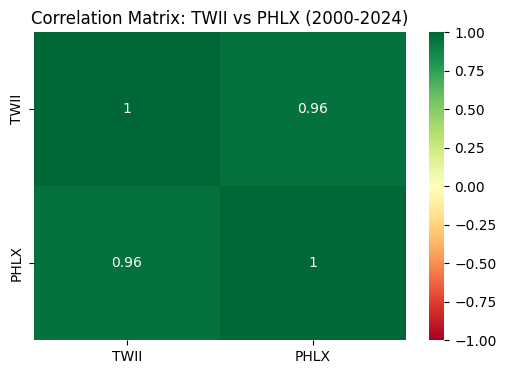

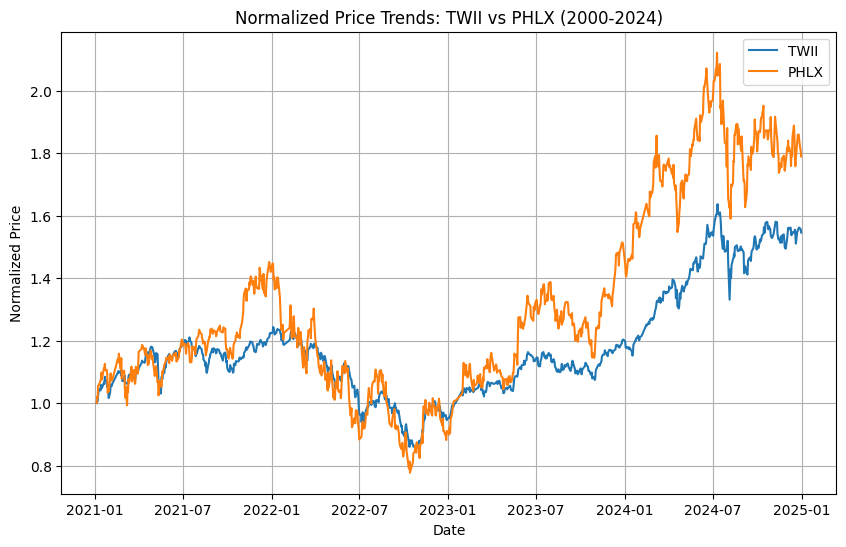

In [4]:
# 安裝必要的庫（如果尚未安裝）
# pip install pandas numpy seaborn matplotlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf

# 定義函數來分析相關係數
def analyze_index_correlation(ticker1, ticker2, file_path1, file_path2, col_name='adj close', start_date='2000-01-01', end_date='2024-12-31'):
    try:
        # 讀取本地 CSV 檔案
        df1 = pd.read_csv(file_path1, index_col=0, parse_dates=True)
        df2 = pd.read_csv(file_path2, index_col=0, parse_dates=True)

        # 檢查欄位名稱
        if col_name not in df1.columns or col_name not in df2.columns:
            print(f"錯誤：{col_name} 不在 {ticker1} 或 {ticker2} 的欄位中")
            print(f"{ticker1} 欄位: {df1.columns}")
            print(f"{ticker2} 欄位: {df2.columns}")
            return None, None, None, None

        # 篩選指定時間範圍
        df1 = df1.loc[start_date:end_date]
        df2 = df2.loc[start_date:end_date]

        # 合併數據並對齊
        data = pd.DataFrame({
            ticker1: df1[col_name],
            ticker2: df2[col_name]
        }).dropna()

        # 檢查數據質量
        print(f"時間範圍: {data.index.min()} 到 {data.index.max()}")
        print(f"數據點數: {len(data)}")
        print(f"缺失值: \n{data.isna().sum()}")
        print(f"數據描述: \n{data.describe()}")


        # 計算 Pearson 相關係數
        correlation = data.corr()


        return data, correlation

    except Exception as e:
        print(f"錯誤: {e}")
        return None, None, None, None

# 設置參數
ticker1 = 'TWII'
ticker2 = 'PHLX'
file_path1 = f'StockData/{ticker1}.csv'
file_path2 = f'StockData/{ticker2}.csv'
col_name = 'close'  # 使用指定的欄位名稱
start_date = '2021-01-01'
end_date = '2024-12-31'


# 計算相關係數
data, correlation = analyze_index_correlation(
    ticker1, ticker2, file_path1, file_path2, col_name, start_date, end_date)

if data is not None:
    # 打印相關係數
    print(f"\n{ticker1} 和 {ticker2} 的相關係數: {correlation.iloc[0, 1]:.4f}")

    # 可視化 1：熱圖
    plt.figure(figsize=(6, 4))
    sns.heatmap(correlation, annot=True, cmap='RdYlGn', vmin=-1, vmax=1)
    plt.title(f'Correlation Matrix: {ticker1} vs {ticker2} (2000-2024)')
    plt.show()


    # 可視化 3：標準化價格走勢圖
    normalized_data = data / data.iloc[0]
    plt.figure(figsize=(10, 6))
    plt.plot(normalized_data[ticker1], label=ticker1)
    plt.plot(normalized_data[ticker2], label=ticker2)
    plt.title(f'Normalized Price Trends: {ticker1} vs {ticker2} (2000-2024)')
    plt.xlabel('Date')
    plt.ylabel('Normalized Price')
    plt.legend()
    plt.grid(True)
    plt.show()
